In [1]:
import pandas as pd
import numpy as np

In [2]:
data= pd.read_csv('amazon.csv')
Odata = pd.read_csv('retail_demand_dataset.csv')

In [3]:
Odata

,date,store_id,product_id,category,price,discount,units_sold,inventory_level,holiday,promotion,temperature,fuel_price
0,2023-01-01,1,P001,Home,112.0,0,15,157,1,1,19.01,99.28
1,2023-01-02,1,P001,Home,106.4,5,18,139,0,0,22.94,95.47
2,2023-01-03,1,P001,Home,112.0,0,9,130,0,0,12.80,96.21
3,2023-01-04,1,P001,Home,89.6,20,25,105,0,0,32.43,95.83
4,2023-01-05,1,P001,Home,95.2,15,21,84,0,0,24.30,94.93
...,...,...,...,...,...,...,...,...,...,...,...,...
54745,2023-12-27,10,P015,Clothing,442.0,0,17,65,0,0,30.91,94.80
54746,2023-12-28,10,P015,Clothing,442.0,0,14,51,0,1,26.76,99.36
54747,2023-12-29,10,P015,Clothing,419.9,5,15,36,0,0,23.76,96.51
54748,2023-12-30,10,P015,Clothing,442.0,0,21,126,1,0,32.84,99.37


In [4]:
data.info

<bound method DataFrame.info of       product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories|Accessories

In [5]:
Odata.info 

<bound method DataFrame.info of              date  store_id product_id  category  price  discount  units_sold  \
0      2023-01-01         1       P001      Home  112.0         0          15   
1      2023-01-02         1       P001      Home  106.4         5          18   
2      2023-01-03         1       P001      Home  112.0         0           9   
3      2023-01-04         1       P001      Home   89.6        20          25   
4      2023-01-05         1       P001      Home   95.2        15          21   
...           ...       ...        ...       ...    ...       ...         ...   
54745  2023-12-27        10       P015  Clothing  442.0         0          17   
54746  2023-12-28        10       P015  Clothing  442.0         0          14   
54747  2023-12-29        10       P015  Clothing  419.9         5          15   
54748  2023-12-30        10       P015  Clothing  442.0         0          21   
54749  2023-12-31        10       P015  Clothing  442.0         0          15

In [6]:
Odata.shape

(54750, 12)

In [7]:
Odata.describe()

,store_id,price,discount,units_sold,inventory_level,holiday,promotion,temperature,fuel_price
count,54750.000000,54750.00000,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,5.500000,255.97775,5.024475,19.365553,78.736511,0.287671,0.297790,25.011704,94.999164
std,2.872308,135.82799,6.125334,5.954674,35.996147,0.452681,0.457291,5.024495,2.001758
min,1.000000,10.40000,0.000000,0.000000,20.000000,0.000000,0.000000,3.960000,86.070000
25%,3.000000,140.60000,0.000000,15.000000,48.000000,0.000000,0.000000,21.620000,93.650000
50%,5.500000,263.15000,5.000000,19.000000,77.000000,0.000000,0.000000,25.020000,95.000000
75%,8.000000,370.50000,10.000000,23.000000,106.000000,1.000000,1.000000,28.407500,96.360000
max,10.000000,499.00000,20.000000,46.000000,186.000000,1.000000,1.000000,46.470000,103.300000


In [8]:
Odata.isnull().sum()

date               0
store_id           0
product_id         0
category           0
price              0
discount           0
units_sold         0
inventory_level    0
holiday            0
promotion          0
temperature        0
fuel_price         0
dtype: int64

In [9]:
Odata['date']= pd.to_datetime(Odata['date'])

In [10]:
Odata['Year']= Odata['date'].dt.year
Odata['Month']= Odata['date'].dt.month
Odata['Day']= Odata['date'].dt.day
Odata['Weekday']= Odata['date'].dt.weekday

In [11]:
Odata["lag_1"] = Odata["units_sold"].shift(1)
Odata["lag_7"] = Odata["units_sold"].shift(7)
Odata["lag_14"] = Odata["units_sold"].shift(14)

In [12]:
Odata2= Odata.copy()

In [13]:
Odata2.head()

,date,store_id,product_id,category,price,discount,units_sold,inventory_level,holiday,promotion,temperature,fuel_price,Year,Month,Day,Weekday,lag_1,lag_7,lag_14
0,2023-01-01,1,P001,Home,112.0,0,15,157,1,1,19.01,99.28,2023,1,1,6,NaN,NaN,NaN
1,2023-01-02,1,P001,Home,106.4,5,18,139,0,0,22.94,95.47,2023,1,2,0,15.0,NaN,NaN
2,2023-01-03,1,P001,Home,112.0,0,9,130,0,0,12.80,96.21,2023,1,3,1,18.0,NaN,NaN
3,2023-01-04,1,P001,Home,89.6,20,25,105,0,0,32.43,95.83,2023,1,4,2,9.0,NaN,NaN
4,2023-01-05,1,P001,Home,95.2,15,21,84,0,0,24.30,94.93,2023,1,5,3,25.0,NaN,NaN


In [14]:
Odata2.dropna()

,date,store_id,product_id,category,price,discount,units_sold,inventory_level,holiday,promotion,temperature,fuel_price,Year,Month,Day,Weekday,lag_1,lag_7,lag_14
14,2023-01-15,1,P001,Home,112.0,0,17,26,1,0,31.37,94.42,2023,1,15,6,36.0,26.0,15.0
15,2023-01-16,1,P001,Home,112.0,0,12,145,0,0,26.73,95.91,2023,1,16,0,17.0,7.0,18.0
16,2023-01-17,1,P001,Home,112.0,0,17,128,0,1,15.41,94.95,2023,1,17,1,12.0,13.0,9.0
17,2023-01-18,1,P001,Home,112.0,0,10,118,0,0,37.32,94.62,2023,1,18,2,17.0,24.0,25.0
18,2023-01-19,1,P001,Home,89.6,20,24,94,0,0,30.71,96.50,2023,1,19,3,10.0,17.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54745,2023-12-27,10,P015,Clothing,442.0,0,17,65,0,0,30.91,94.80,2023,12,27,2,19.0,14.0,12.0
54746,2023-12-28,10,P015,Clothing,442.0,0,14,51,0,1,26.76,99.36,2023,12,28,3,17.0,19.0,23.0
54747,2023-12-29,10,P015,Clothing,419.9,5,15,36,0,0,23.76,96.51,2023,12,29,4,14.0,27.0,26.0
54748,2023-12-30,10,P015,Clothing,442.0,0,21,126,1,0,32.84,99.37,2023,12,30,5,15.0,28.0,17.0


In [20]:
features = [
    "price",
    "discount",
    "inventory_level",
    "promotion",
    "holiday",
    "Month",
    "Weekday",
    "lag_1",
    "lag_7",
    "lag_14"
]

In [21]:
target = "units_sold"

In [22]:
from sklearn.model_selection import train_test_split

In [25]:
x= Odata[features]
y= Odata[target]

x_train,x_test, y_train, y_test = train_test_split(
    x,y,test_size = 0.2, random_state= 42
)

In [35]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(43800, 10)
(10950, 10)
(43800,)
(10950,)


In [31]:
x_test.columns

Index(['price', 'discount', 'inventory_level', 'promotion', 'holiday', 'Month',
       'Weekday', 'lag_1', 'lag_7', 'lag_14'],
      dtype='object')

In [32]:
x_train.columns

Index(['price', 'discount', 'inventory_level', 'promotion', 'holiday', 'Month',
       'Weekday', 'lag_1', 'lag_7', 'lag_14'],
      dtype='object')

In [37]:
x_train.head()

,price,discount,inventory_level,promotion,holiday,Month,Weekday,lag_1,lag_7,lag_14
23522,268.00,0,37,0,0,6,0,25.0,11.0,15.0
47823,470.25,5,33,0,0,1,0,13.0,17.0,13.0
44038,76.95,5,127,1,1,8,6,18.0,14.0,25.0
39268,267.00,0,26,0,0,8,2,19.0,33.0,12.0
7237,337.50,10,32,1,0,10,0,14.0,27.0,14.0


In [38]:
x_test.head()

,price,discount,inventory_level,promotion,holiday,Month,Weekday,lag_1,lag_7,lag_14
6246,382.0,0,41,1,1,2,5,19.0,8.0,15.0
32248,41.8,5,125,0,0,5,1,13.0,21.0,19.0
49338,317.0,0,32,0,1,3,6,16.0,21.0,36.0
35720,366.7,5,107,0,1,11,6,22.0,23.0,16.0
28751,62.0,0,21,0,0,10,0,19.0,26.0,21.0


In [40]:
print(len(x_test)/len(Odata))
print(len(x_train)/len(Odata))

0.2
0.8


In [42]:
Odata.columns

Index(['date', 'store_id', 'product_id', 'category', 'price', 'discount',
       'units_sold', 'inventory_level', 'holiday', 'promotion', 'temperature',
       'fuel_price', 'Year', 'Month', 'Day', 'Weekday', 'lag_1', 'lag_7',
       'lag_14'],
      dtype='object')

In [43]:
print(x_test.shape,x_train.shape)

(10950, 10) (43800, 10)


In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
predictions = model.predict(x_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test,predictions)
rmse = np.sqrt(mean_squared_error(y_test,predictions))

print("MAE:", mae)
print('RMSE:', rmse)

MAE: 3.6103954337899546
RMSE: 4.512051874560116


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

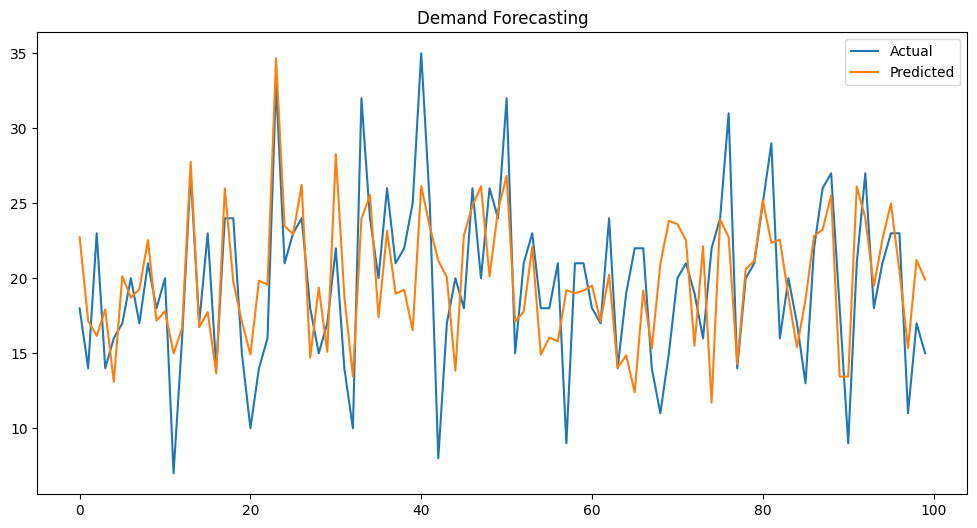

In [61]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label= 'Actual')
plt.plot(predictions[:100], label = "Predicted")

plt.legend()
plt.title('Demand Forecasting')
plt.show()